# 05 Modeling Baselines SVM

Baseline TF-IDF sentiment classification experiments for the final 1,000-row MBG labeled sample. Macro F1 is prioritized because the dataset is class-imbalanced; accuracy is reported but not used alone as the main conclusion. These are baseline modeling experiments, not final thesis results.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "mbg_labeled_sample_1000.csv"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

## Load Final Labeled Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 1,000
Columns: ['batch_id', 'sample_id', 'clean_text', 'label', 'label_before_adjudication', 'label_after_adjudication', 'adjudication_applied', 'human_label', 'human_notes', 'adjudication_review_reason']


,batch_id,sample_id,clean_text,label,label_before_adjudication,label_after_adjudication,adjudication_applied,human_label,human_notes,adjudication_review_reason
0,1,label_sample_0001,belum selesai lomba di mbg sekarang udah di li...,netral,netral,netral,True,netral,teks ambigu tanpa polaritas jelas,catatan menunjukkan konteks ambigu/informatif
1,1,label_sample_0002,good job polri rekrut gizi spesialis buat mbg ...,positif,positif,positif,False,NaN,NaN,NaN
2,1,label_sample_0003,dapoer ibu boyolali terus salurkan mbg untuk p...,positif,netral,positif,True,positif,seperti support mbg,catatan menunjukkan konteks ambigu/informatif
3,1,label_sample_0004,duitnya buat mbg ga bisa bayar artist lokal,negatif,negatif,negatif,False,NaN,NaN,NaN
4,1,label_sample_0005,deket rumah udah ada simulasi makan bergizi gr...,netral,netral,netral,True,netral,informasi simulasi tanpa opini,catatan menunjukkan konteks ambigu/informatif


## Label Distribution

In [3]:
label_counts = df["label"].value_counts().rename("count")
label_distribution = label_counts.to_frame()
label_distribution["percentage"] = (label_distribution["count"] / len(df) * 100).round(2)
label_distribution

,count,percentage
label,,
netral,472,47.2
positif,412,41.2
negatif,116,11.6


## Run Baseline Modeling Script Logic

In [4]:
from run_modeling_baselines import run_baselines

summary = run_baselines()
summary["best_model"]

Loaded dataset: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\data\processed\mbg_labeled_sample_1000.csv
Total rows: 1000
Label distribution:
  negatif: 116 (11.60%)
  netral: 472 (47.20%)
  positif: 412 (41.20%)
Evaluating Multinomial Naive Bayes...


Evaluating Logistic Regression...


Evaluating Linear SVM...


Evaluating RBF SVM...


CV results saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\14_modeling_cv_results.csv
Test results saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\14_modeling_test_results.csv
Summary JSON saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\14_modeling_baseline_summary.json
Markdown report saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\14_modeling_baseline_report.md
Best model saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\models\best_baseline_model.joblib
Best model metadata saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\models\best_baseline_model_metadata.json
Best model by test macro F1: Logistic Regression (0.7151)


{'model': 'logistic_regression',
 'model_display_name': 'Logistic Regression',
 'selection_metric': 'test_f1_macro',
 'test_f1_macro': 0.7150707178275484,
 'artifact_path': 'C:\\Users\\hpdk1\\Documents\\Projects\\mbg-sentiment-analysis\\outputs\\models\\best_baseline_model.joblib',
 'metadata_path': 'C:\\Users\\hpdk1\\Documents\\Projects\\mbg-sentiment-analysis\\outputs\\models\\best_baseline_model_metadata.json'}

## Cross-Validation Results

In [5]:
cv_results = pd.read_csv(REPORTS_DIR / "14_modeling_cv_results.csv")
cv_results

,model,model_display_name,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,logistic_regression,Logistic Regression,0.780,0.019494,0.714261,0.016821,0.700050,0.023434,0.702280,0.018922,0.778501,0.016955
1,linear_svm,Linear SVM,0.778,0.023152,0.690514,0.028237,0.661354,0.014583,0.669800,0.018014,0.770467,0.019260
2,rbf_svm,RBF SVM,0.756,0.032000,0.735598,0.089830,0.586365,0.028669,0.582885,0.032300,0.724167,0.029239
3,multinomial_nb,Multinomial Naive Bayes,0.732,0.019131,0.493026,0.015392,0.552313,0.014237,0.519559,0.014085,0.687299,0.018337


## Test Results

In [6]:
test_results = pd.read_csv(REPORTS_DIR / "14_modeling_test_results.csv")
test_results

,model,model_display_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,logistic_regression,Logistic Regression,0.775,0.716421,0.721140,0.715071,0.778398
1,linear_svm,Linear SVM,0.765,0.720340,0.682839,0.697124,0.760918
2,rbf_svm,RBF SVM,0.760,0.735897,0.599661,0.607241,0.735115
3,multinomial_nb,Multinomial Naive Bayes,0.730,0.495833,0.548438,0.518653,0.686919


## Confusion Matrices

14_confusion_matrix_multinomial_nb.png


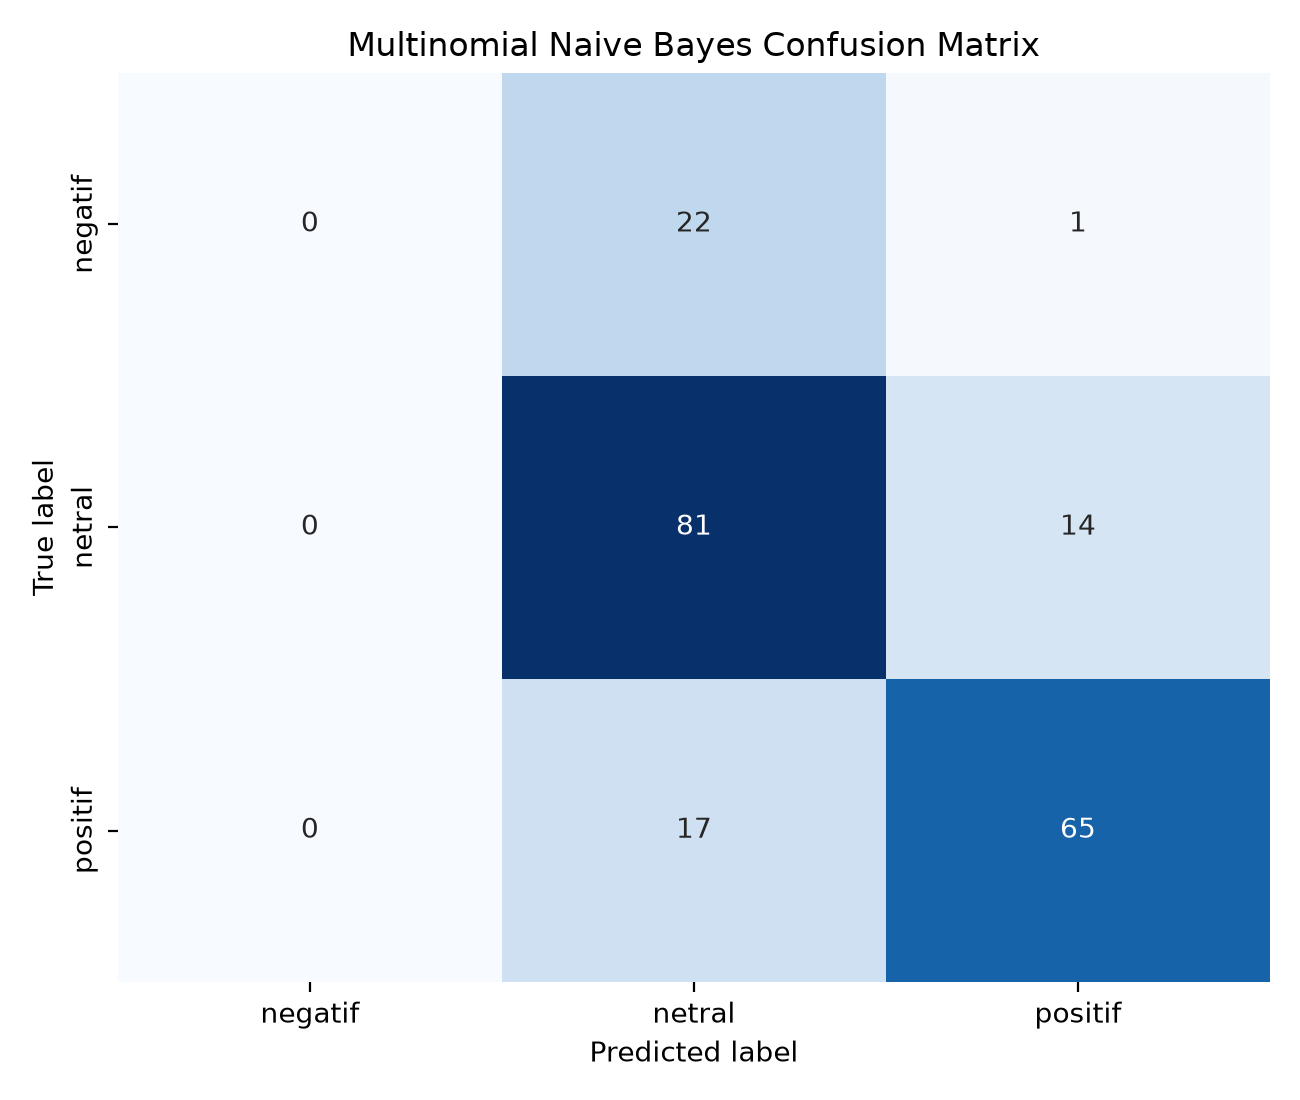

14_confusion_matrix_logistic_regression.png


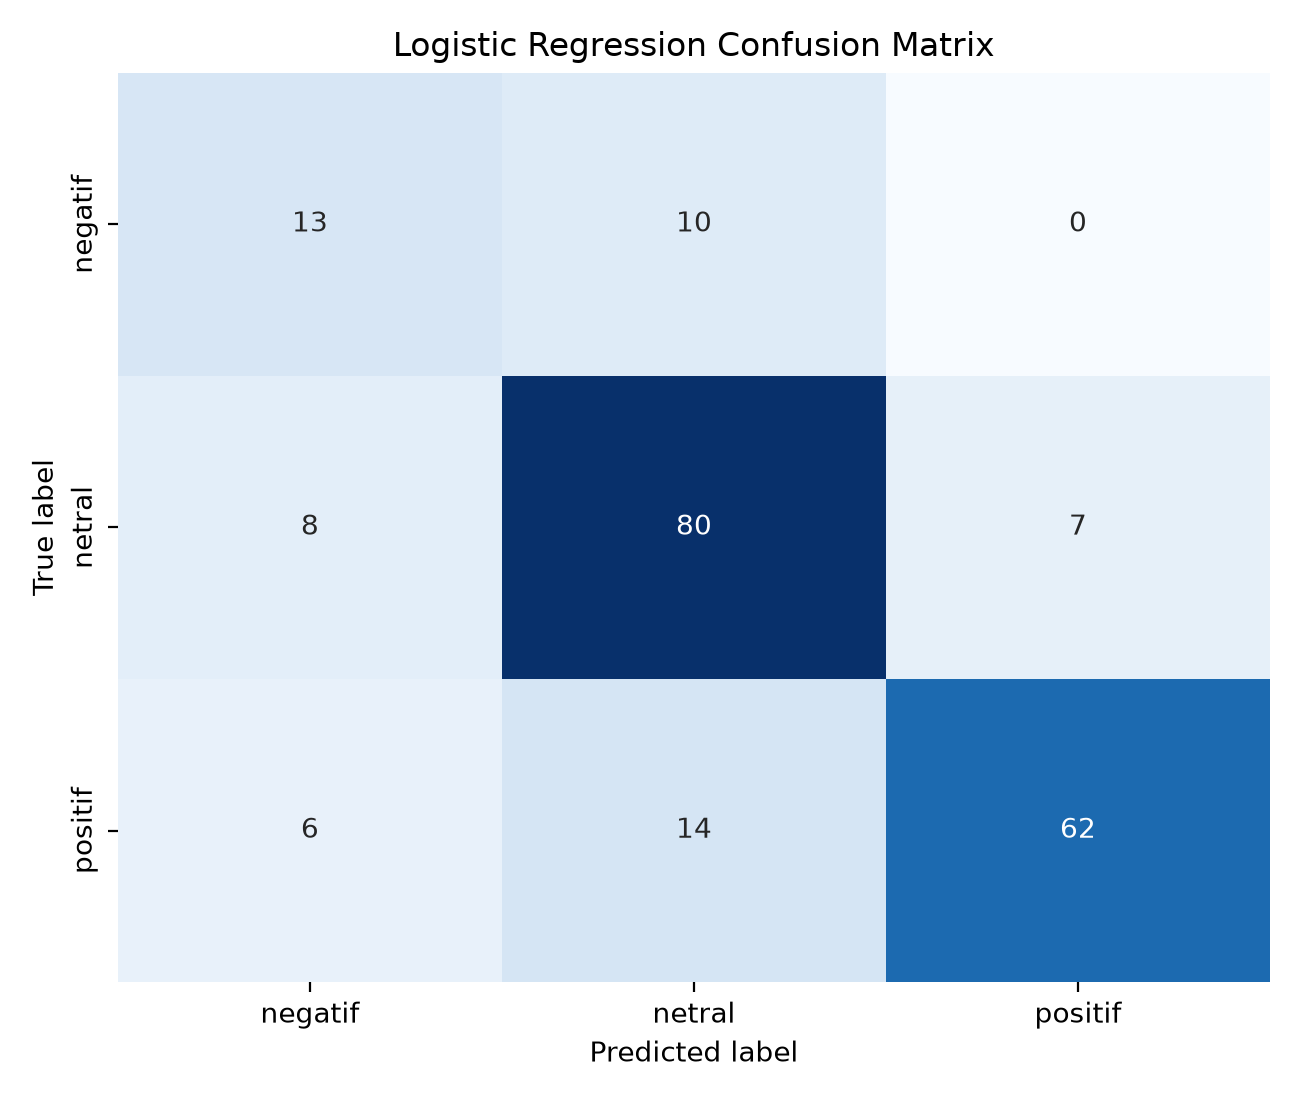

14_confusion_matrix_linear_svm.png


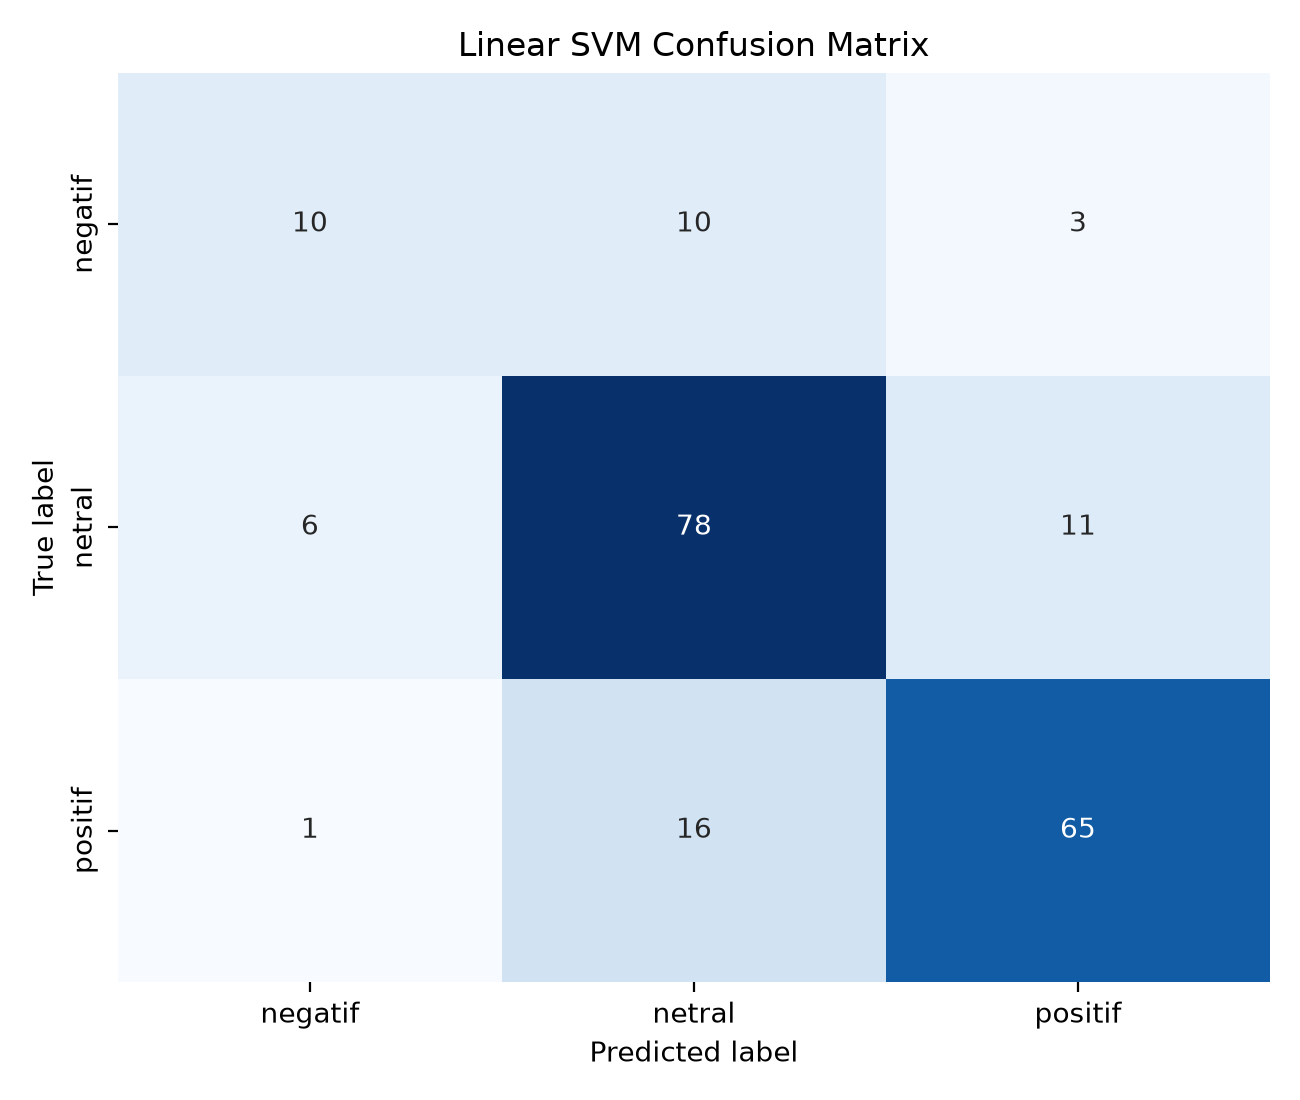

14_confusion_matrix_rbf_svm.png


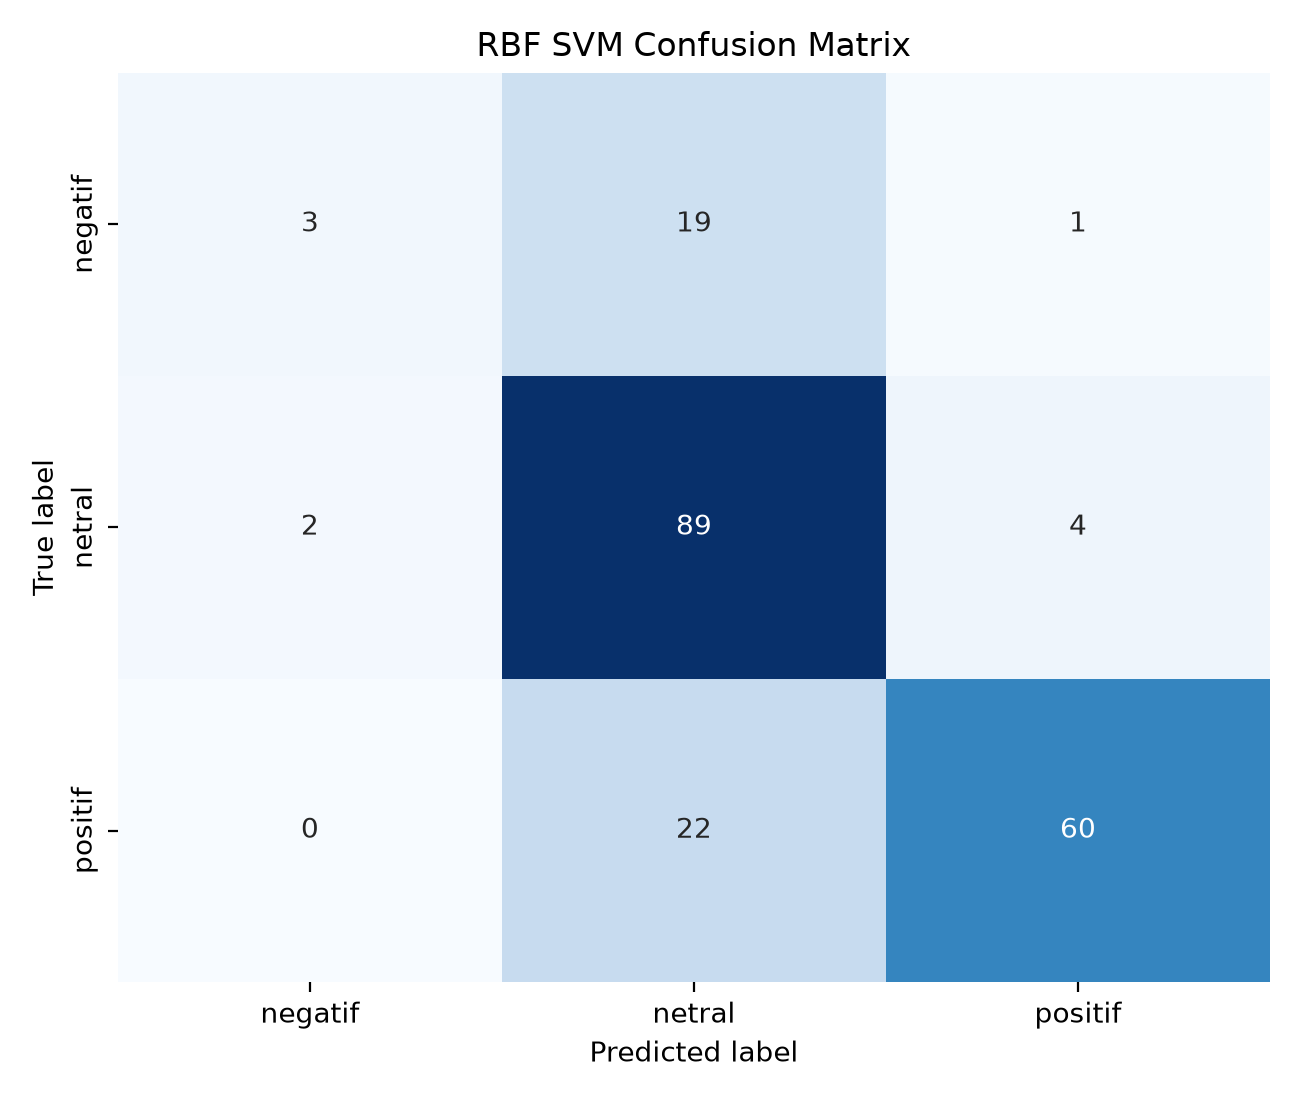

In [7]:
confusion_matrix_paths = [
    FIGURES_DIR / "14_confusion_matrix_multinomial_nb.png",
    FIGURES_DIR / "14_confusion_matrix_logistic_regression.png",
    FIGURES_DIR / "14_confusion_matrix_linear_svm.png",
    FIGURES_DIR / "14_confusion_matrix_rbf_svm.png",
]
for path in confusion_matrix_paths:
    print(path.name)
    display(Image(filename=str(path)))

## Best Model by Macro F1

In [8]:
with open(REPORTS_DIR / "14_modeling_baseline_summary.json", encoding="utf-8") as file_obj:
    saved_summary = json.load(file_obj)

best_model = saved_summary["best_model"]
print(f"Best baseline model by test macro F1: {best_model['model_display_name']} ({best_model['model']})")
print(f"Test macro F1: {best_model['test_f1_macro']:.4f}")
print(f"Model artifact: {best_model['artifact_path']}")

Best baseline model by test macro F1: Logistic Regression (logistic_regression)
Test macro F1: 0.7151
Model artifact: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\models\best_baseline_model.joblib
